# preprocessing

In [27]:
import pandas as pd
import numpy as np

df = pd.read_csv('../datasets/ecommerce_company_client_churn_data.csv')
df.head()

,user_id,platform,market_country,user_creation_datetime,confirmation_datetime,first_purchase_datetime,last_purchase_datetime,first_integration_datetime,last_segment_recorded,longevity,...,historic_aov,csat,cs_tickets_good,cs_tickets_offered,cs_tickets_unoffered,cs_tickets_bad,customer_feedback_tickets,total_tickets,churn_factor,status
0,a571a717903d731460c3f8b012897aa6,4128403e5dad4f40eb5c79a92a5719c9,6b681da4aa6e2f33a5f06ff660ba0e9e,2019-06-10 17:10:15 UTC,2019-06-10 17:10:15 UTC,2019-08-19 16:01:43 UTC,2021-03-06 18:21:17 UTC,2019-08-19 16:01:43 UTC,S,974,...,14.455833,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20.098765,churned
1,c681dc7c20837e3ea7a0c0531e3d4eb6,4128403e5dad4f40eb5c79a92a5719c9,64f6711e77d2ec8af8ac3292c66d2875,2019-03-12 09:52:44 UTC,2019-03-12 09:52:44 UTC,2019-03-12 10:31:17 UTC,2022-04-17 15:54:31 UTC,2019-03-12 10:31:17 UTC,S,1134,...,9.582500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,ok
2,9d8cbbb590831fb2e61b4dbefe4543d4,c44577a5b4c0036fe1ec82c04bfa87c6,9a6e56e83f8d0f692203f7b4850f86ff,2019-08-30 14:04:15 UTC,2019-08-30 14:04:15 UTC,2019-09-09 20:23:35 UTC,2022-04-15 06:28:45 UTC,2019-11-26 17:34:22 UTC,Non-recurring,953,...,129.056800,1.0,7.0,8.0,4.0,0.0,7.0,19.0,0.716842,ok
3,3ce08777163438749f3110c10b72d6be,4128403e5dad4f40eb5c79a92a5719c9,c097bb1538327aaf74797d23f6fcef83,2020-08-16 20:56:37 UTC,2020-08-16 20:56:37 UTC,2020-08-16 21:04:41 UTC,2022-04-08 08:31:15 UTC,2020-08-16 21:04:41 UTC,M,611,...,12.827273,NaN,0.0,3.0,0.0,0.0,0.0,3.0,0.482529,ok
4,36989756b0656e71577f284a7e7af62a,4128403e5dad4f40eb5c79a92a5719c9,c097bb1538327aaf74797d23f6fcef83,2020-04-24 08:25:17 UTC,2020-04-24 08:25:17 UTC,2020-05-26 09:28:55 UTC,2022-03-14 11:43:35 UTC,2020-05-26 09:28:55 UTC,S,693,...,19.607500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.542553,ok


In [28]:
# 타겟 변수 생성
df['Churn'] = df['status'].map({'ok': 0, 'churned': 1})

df['Churn'].value_counts()

Churn
0    508
1    492
Name: count, dtype: int64

In [29]:
# 변수 제거
# 'churn_factor'는 데이터 누수 방지 위해 제거
# 'platform'과 'market_country'는 데이터 식별 불가로 제거
drop_cols = ['status', 'user_id', 'churn_factor', 'platform', 'market_country']  
df = df.drop(columns=drop_cols)

df.head()

,user_creation_datetime,confirmation_datetime,first_purchase_datetime,last_purchase_datetime,first_integration_datetime,last_segment_recorded,longevity,total_sales,avg_sales_per_day,min_days_btwn_sales,...,previous_year_plat_cntry_aov,historic_aov,csat,cs_tickets_good,cs_tickets_offered,cs_tickets_unoffered,cs_tickets_bad,customer_feedback_tickets,total_tickets,Churn
0,2019-06-10 17:10:15 UTC,2019-06-10 17:10:15 UTC,2019-08-19 16:01:43 UTC,2021-03-06 18:21:17 UTC,2019-08-19 16:01:43 UTC,S,974,36,0.0370,0,...,6.062347,14.455833,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
1,2019-03-12 09:52:44 UTC,2019-03-12 09:52:44 UTC,2019-03-12 10:31:17 UTC,2022-04-17 15:54:31 UTC,2019-03-12 10:31:17 UTC,S,1134,35,0.0309,0,...,3.460839,9.582500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2,2019-08-30 14:04:15 UTC,2019-08-30 14:04:15 UTC,2019-09-09 20:23:35 UTC,2022-04-15 06:28:45 UTC,2019-11-26 17:34:22 UTC,Non-recurring,953,568,0.5960,0,...,7.058973,129.056800,1.0,7.0,8.0,4.0,0.0,7.0,19.0,0
3,2020-08-16 20:56:37 UTC,2020-08-16 20:56:37 UTC,2020-08-16 21:04:41 UTC,2022-04-08 08:31:15 UTC,2020-08-16 21:04:41 UTC,M,611,43,0.0704,0,...,4.097984,12.827273,NaN,0.0,3.0,0.0,0.0,0.0,3.0,0
4,2020-04-24 08:25:17 UTC,2020-04-24 08:25:17 UTC,2020-05-26 09:28:55 UTC,2022-03-14 11:43:35 UTC,2020-05-26 09:28:55 UTC,S,693,36,0.0519,0,...,4.097984,19.607500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0


In [30]:
[col for col in df.columns if 'date' in col.lower() or 'time' in col.lower()]

['user_creation_datetime',
 'confirmation_datetime',
 'first_purchase_datetime',
 'last_purchase_datetime',
 'first_integration_datetime',
 'min_days_btwn_sale_date',
 'fst_quartile_days_btwn_sale_date',
 'avg_days_btwn_sale_date',
 'median_days_btwn_sale_date',
 'thrd_quartile_days_btwn_sale_date']

In [31]:
# 날짜 컬럼 확인    
datetime_cols = ['user_creation_datetime',
 'confirmation_datetime',
 'first_purchase_datetime',
 'last_purchase_datetime',
 'first_integration_datetime',
 'min_days_btwn_sale_date',
 'fst_quartile_days_btwn_sale_date',
 'avg_days_btwn_sale_date',
 'median_days_btwn_sale_date',
 'thrd_quartile_days_btwn_sale_date']

In [32]:
# x, y 분리
X = df.drop('Churn', axis=1)
y = df['Churn']

print(X.shape, y.shape)

(1000, 46) (1000,)


In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (800, 46)
X_test: (200, 46)
y_train: (800,)
y_test: (200,)


In [34]:
# 타겟 분리 확인
print("전체 비율")
print(y.value_counts(normalize=True))

print("\ntrain 비율")
print(y_train.value_counts(normalize=True))

print("\ntest 비율")
print(y_test.value_counts(normalize=True))

전체 비율
Churn
0    0.508
1    0.492
Name: proportion, dtype: float64

train 비율
Churn
0    0.5075
1    0.4925
Name: proportion, dtype: float64

test 비율
Churn
0    0.51
1    0.49
Name: proportion, dtype: float64


In [35]:
for col in datetime_cols:
    X_train[col] = pd.to_datetime(X_train[col], errors='coerce')
    X_test[col] = pd.to_datetime(X_test[col], errors='coerce')

In [36]:
X_train[datetime_cols].dtypes

user_creation_datetime               datetime64[us, UTC]
confirmation_datetime                datetime64[us, UTC]
first_purchase_datetime              datetime64[us, UTC]
last_purchase_datetime               datetime64[us, UTC]
first_integration_datetime           datetime64[us, UTC]
min_days_btwn_sale_date                   datetime64[ns]
fst_quartile_days_btwn_sale_date          datetime64[ns]
avg_days_btwn_sale_date                   datetime64[ns]
median_days_btwn_sale_date                datetime64[ns]
thrd_quartile_days_btwn_sale_date         datetime64[ns]
dtype: object

In [37]:
train_datetime_missing = X_train[datetime_cols].isnull().sum().sort_values(ascending=False)
train_datetime_missing

first_integration_datetime           322
confirmation_datetime                220
median_days_btwn_sale_date             1
min_days_btwn_sale_date                1
avg_days_btwn_sale_date                1
fst_quartile_days_btwn_sale_date       1
thrd_quartile_days_btwn_sale_date      1
user_creation_datetime                 0
first_purchase_datetime                0
last_purchase_datetime                 0
dtype: int64

In [38]:
train_datetime_missing_ratio = (X_train[datetime_cols].isnull().mean() * 100).sort_values(ascending=False)
train_datetime_missing_ratio

first_integration_datetime           40.250
confirmation_datetime                27.500
median_days_btwn_sale_date            0.125
min_days_btwn_sale_date               0.125
avg_days_btwn_sale_date               0.125
fst_quartile_days_btwn_sale_date      0.125
thrd_quartile_days_btwn_sale_date     0.125
user_creation_datetime                0.000
first_purchase_datetime               0.000
last_purchase_datetime                0.000
dtype: float64

## 파생변수 만들기
- 모델을 돌리기 위해서 날짜를 기간으로 바꿈

In [39]:
# 날짜 파생 변수 만들기
# 가입 후 첫 구매까지 걸린 일수

if {'user_creation_datetime', 'first_purchase_datetime'}.issubset(X_train.columns):
    X_train['days_to_first_purchase'] = (
        X_train['first_purchase_datetime'] - X_train['user_creation_datetime']
    ).dt.days

    X_test['days_to_first_purchase'] = (
        X_test['first_purchase_datetime'] - X_test['user_creation_datetime']
    ).dt.days

In [40]:
# 가입 후 마지막 구매까지 기간
X_train['days_from_signup_to_last_purchase'] = (
    X_train['last_purchase_datetime'] - X_train['user_creation_datetime']
).dt.days

X_test['days_from_signup_to_last_purchase'] = (
    X_test['last_purchase_datetime'] - X_test['user_creation_datetime']
).dt.days

In [41]:
# 가입 후 인증까지 걸린 일수
if {'user_creation_datetime', 'confirmation_datetime'}.issubset(X_train.columns):
    X_train['days_to_confirmation'] = (
        X_train['confirmation_datetime'] - X_train['user_creation_datetime']
    ).dt.days

    X_test['days_to_confirmation'] = (
        X_test['confirmation_datetime'] - X_test['user_creation_datetime']
    ).dt.days

In [42]:
# 가입 후 첫 연동까지 걸린 일수
if {'user_creation_datetime', 'first_integration_datetime'}.issubset(X_train.columns):
    X_train['days_to_first_integration'] = (
        X_train['first_integration_datetime'] - X_train['user_creation_datetime']
    ).dt.days

    X_test['days_to_first_integration'] = (
        X_test['first_integration_datetime'] - X_test['user_creation_datetime']
    ).dt.days

In [43]:
# 파생변수 확인
new_date_features = [
    col for col in X_train.columns
    if col.startswith('days_')
]

new_date_features

['days_to_first_purchase',
 'days_from_signup_to_last_purchase',
 'days_to_confirmation',
 'days_to_first_integration']

In [44]:
X_train[new_date_features].describe().T

,count,mean,std,min,25%,50%,75%,max
days_to_first_purchase,800.0,151.010000,397.479713,-651.0,0.00,0.0,26.25,2808.0
days_from_signup_to_last_purchase,800.0,577.787500,583.759343,2.0,143.75,412.0,774.25,3456.0
days_to_confirmation,580.0,4.375862,96.098180,0.0,0.00,0.0,0.00,2313.0
days_to_first_integration,478.0,109.587866,295.827567,0.0,0.00,0.0,16.00,1936.0


- 일부 날짜 파생변수에서 음수 값이 발생

In [45]:
# 원본 날짜 컬럼 제거
X_train = X_train.drop(columns=datetime_cols)
X_test = X_test.drop(columns=datetime_cols)

## 결측치 확인

In [46]:
missing_count = X_train.isnull().sum().sort_values(ascending=False)
missing_count[missing_count > 0]

csat                            763
previous_year_revenue_eur       690
previous_year_label_count       690
previous_year_aov               690
total_tickets                   640
customer_feedback_tickets       640
cs_tickets_good                 640
cs_tickets_offered              640
cs_tickets_unoffered            640
cs_tickets_bad                  640
days_to_first_integration       322
days_to_confirmation            220
previous_year_plat_cntry_aov     11
dtype: int64

In [47]:
missing_ratio = (X_train.isnull().mean() * 100).sort_values(ascending=False)
missing_ratio[missing_ratio > 0]

csat                            95.375
previous_year_revenue_eur       86.250
previous_year_label_count       86.250
previous_year_aov               86.250
total_tickets                   80.000
customer_feedback_tickets       80.000
cs_tickets_good                 80.000
cs_tickets_offered              80.000
cs_tickets_unoffered            80.000
cs_tickets_bad                  80.000
days_to_first_integration       40.250
days_to_confirmation            27.500
previous_year_plat_cntry_aov     1.375
dtype: float64

In [48]:
missing_summary = pd.DataFrame({
    'missing_count': X_train.isnull().sum(),
    'missing_ratio(%)': X_train.isnull().mean() * 100
}).sort_values(by='missing_ratio(%)', ascending=False)

missing_summary[missing_summary['missing_count'] > 0]

,missing_count,missing_ratio(%)
csat,763,95.375
previous_year_revenue_eur,690,86.250
previous_year_label_count,690,86.250
previous_year_aov,690,86.250
total_tickets,640,80.000
customer_feedback_tickets,640,80.000
cs_tickets_good,640,80.000
cs_tickets_offered,640,80.000
cs_tickets_unoffered,640,80.000
cs_tickets_bad,640,80.000


In [49]:
# 수치형 범주형 다시 분리
numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()

print("수치형 변수 수:", len(numeric_cols))
print("범주형 변수 수:", len(categorical_cols))

print("\n수치형 변수:")
print(numeric_cols)

print("\n범주형 변수:")
print(categorical_cols)

수치형 변수 수: 39
범주형 변수 수: 1

수치형 변수:
['longevity', 'total_sales', 'avg_sales_per_day', 'min_days_btwn_sales', 'frst_quartile_days_btwn_sales', 'avg_days_btwn_sales', 'median_days_btwn_sales', 'thrd_quartile_days_btwn_sales', 'max_days_btwn_sales', 'frequency', 'recency', 'month_label_count', 'quarter_label_count', 'year_label_count', 'previous_year_label_count', 'historic_label_count', 'month_revenue_eur', 'quarter_revenue_eur', 'year_revenue_eur', 'previous_year_revenue_eur', 'historic_revenue_eur', 'month_average_order_value', 'quarter_aov', 'year_aov', 'year_plat_cntry_aov', 'previous_year_aov', 'previous_year_plat_cntry_aov', 'historic_aov', 'csat', 'cs_tickets_good', 'cs_tickets_offered', 'cs_tickets_unoffered', 'cs_tickets_bad', 'customer_feedback_tickets', 'total_tickets', 'days_to_first_purchase', 'days_from_signup_to_last_purchase', 'days_to_confirmation', 'days_to_first_integration']

범주형 변수:
['last_segment_recorded']


C:\Users\sunny\AppData\Local\Temp\ipykernel_33520\142455813.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()


In [50]:
for col in categorical_cols:
    print(f"\n[{col}]")
    print(X_train[col].nunique())
    print(X_train[col].value_counts(dropna=False).head())


[last_segment_recorded]
5
last_segment_recorded
S                422
Non-recurring    295
M                 68
L                 14
XL                 1
Name: count, dtype: int64


### 고결측 컬럼 제거

In [ ]:
# 결측치 비율이 지나치게 높은 변수들은 모델의 안정성을 해칠 수 있으므로 제거
high_missing_cols = [
    'csat',
    'previous_year_revenue_eur',
    'previous_year_label_count',
    'previous_year_aov',
    'total_tickets',
    'customer_feedback_tickets',
    'cs_tickets_good',
    'cs_tickets_offered',
    'cs_tickets_unoffered',
    'cs_tickets_bad'
]

In [52]:
high_missing_cols = [col for col in high_missing_cols if col in X_train.columns]

X_train = X_train.drop(columns=high_missing_cols)
X_test = X_test.drop(columns=high_missing_cols)

print("제거된 고결측 컬럼 수:", len(high_missing_cols))
print(high_missing_cols)

제거된 고결측 컬럼 수: 10
['csat', 'previous_year_revenue_eur', 'previous_year_label_count', 'previous_year_aov', 'total_tickets', 'customer_feedback_tickets', 'cs_tickets_good', 'cs_tickets_offered', 'cs_tickets_unoffered', 'cs_tickets_bad']


## 수치형 (날짜 파생변수) 이상치 및 결측치 처리

In [53]:
# 음수값을 NaN으로 바꾸기
date_feature_cols = [
    'days_to_first_purchase',
    'days_from_signup_to_last_purchase',
    'days_to_confirmation',
    'days_to_first_integration'
]

for col in date_feature_cols:
    if col in X_train.columns:
        X_train.loc[X_train[col] < 0, col] = np.nan
        X_test.loc[X_test[col] < 0, col] = np.nan

In [54]:
X_train[date_feature_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
days_to_first_purchase,781.0,158.713188,397.748564,0.0,0.00,0.0,32.00,2808.0
days_from_signup_to_last_purchase,800.0,577.787500,583.759343,2.0,143.75,412.0,774.25,3456.0
days_to_confirmation,580.0,4.375862,96.098180,0.0,0.00,0.0,0.00,2313.0
days_to_first_integration,478.0,109.587866,295.827567,0.0,0.00,0.0,16.00,1936.0


In [55]:
# 단순 누락이라기보다 그 행동 자체가 없었던 것일 수 있음
# 따라서 median으로 채우는 것보다,의미 있는 특수값(-1) 로 채움
special_na_cols = ['days_to_confirmation', 'days_to_first_integration']

for col in special_na_cols:
    if col in X_train.columns:
        X_train[col] = X_train[col].fillna(-1)
        X_test[col] = X_test[col].fillna(-1)

In [56]:
# 수치형 / 범주형 다시 분리
numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()

print("수치형 변수 수:", len(numeric_cols))
print("범주형 변수 수:", len(categorical_cols))

print("범주형 변수:", categorical_cols)

수치형 변수 수: 29
범주형 변수 수: 1
범주형 변수: ['last_segment_recorded']


C:\Users\sunny\AppData\Local\Temp\ipykernel_33520\2775589429.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()


In [57]:
# 날짜 제외 나머지 수치형 변수 중앙값으로 결측치 채우기
for col in numeric_cols:
    median_value = X_train[col].median()
    X_train[col] = X_train[col].fillna(median_value)
    X_test[col] = X_test[col].fillna(median_value)

## 범주형 변수 인코딩
- 결측치는 없음
- S, Non-recurring, M, L, XL (의미있는 범주형 변수) -> One-Hot Encoding

In [59]:
# get_dummies 적용
X_train = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

In [60]:
# train/test 컬럼 맞추기
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [ ]:
# 최종 결측치 확인
print("X_train 결측치 총합:", X_train.isnull().sum().sum())
print("X_test 결측치 총합:", X_test.isnull().sum().sum())

X_train 결측치 총합: 0
X_test 결측치 총합: 0


In [62]:
# 최종 데이터 형태 및 타입 확인
print(X_train.shape)
print(X_test.shape)

print(X_train.dtypes.value_counts())

(800, 33)
(200, 33)
float64    16
int64      13
bool        4
Name: count, dtype: int64


# 스케일링
- recency / frequency 중심 + 비선형 + 이상치 존재
- Logistic → 스케일링
- Tree 계열 → 그냥 사용

In [63]:
# 스케일링 (RobustScaler)
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()    # 이상치 많았던것을 고려해서 RobustScaler 사용

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [64]:
# 평가함수 만들기
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

def evaluate_model(model, X_test, y_test, name="Model"):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    print(f"\n📌 {name}")
    print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
    print("Precision:", round(precision_score(y_test, y_pred), 4))
    print("Recall:", round(recall_score(y_test, y_pred), 4))
    print("F1 Score:", round(f1_score(y_test, y_pred), 4))
    print("ROC AUC:", round(roc_auc_score(y_test, y_prob), 4))

# modeling

In [65]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_scaled, y_train)

evaluate_model(lr, X_test_scaled, y_test, "Logistic Regression")


📌 Logistic Regression
Accuracy: 0.96
Precision: 0.9688
Recall: 0.949
F1 Score: 0.9588
ROC AUC: 0.9952


c:\playdata\workspace\project2\SKN28-2nd-4Team\myenv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [66]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

evaluate_model(rf, X_test, y_test, "Random Forest")


📌 Random Forest
Accuracy: 0.94
Precision: 0.9778
Recall: 0.898
F1 Score: 0.9362
ROC AUC: 0.9932


In [67]:
# XGBoost
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

evaluate_model(xgb, X_test, y_test, "XGBoost")


📌 XGBoost
Accuracy: 0.96
Precision: 0.9592
Recall: 0.9592
F1 Score: 0.9592
ROC AUC: 0.9957


c:\playdata\workspace\project2\SKN28-2nd-4Team\myenv\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:56:33] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


- XGBoost가 이탈 고객을 가장 잘 잡는 최적의 모델

## Threshold Tuning
-최종 모델인 xgboost 튜닝   

In [68]:
y_prob = xgb.predict_proba(X_test)[:, 1]

In [69]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.1, 0.9, 0.05)

results = []

for t in thresholds:
    y_pred = (y_prob >= t).astype(int)

    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append([t, precision, recall, f1])

In [70]:
import pandas as pd

threshold_df = pd.DataFrame(results, columns=['threshold', 'precision', 'recall', 'f1'])

threshold_df

,threshold,precision,recall,f1
0,0.10,0.941176,0.979592,0.960000
1,0.15,0.960000,0.979592,0.969697
2,0.20,0.960000,0.979592,0.969697
3,0.25,0.959596,0.969388,0.964467
4,0.30,0.959184,0.959184,0.959184
5,0.35,0.959184,0.959184,0.959184
6,0.40,0.959184,0.959184,0.959184
7,0.45,0.959184,0.959184,0.959184
8,0.50,0.959184,0.959184,0.959184
9,0.55,0.969072,0.959184,0.964103


- Recall을 최대화하면서 Precision 손실이 최소인 threshold 0.15를 선택

In [71]:
best_threshold = 0.15

In [72]:
y_prob = xgb.predict_proba(X_test)[:, 1]

y_final = (y_prob >= best_threshold).astype(int)

In [73]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print("📌 Final Model (XGBoost + Threshold 0.15)\n")

print("Accuracy:", round(accuracy_score(y_test, y_final), 4))
print("Precision:", round(precision_score(y_test, y_final), 4))
print("Recall:", round(recall_score(y_test, y_final), 4))
print("F1 Score:", round(f1_score(y_test, y_final), 4))

📌 Final Model (XGBoost + Threshold 0.15)

Accuracy: 0.97
Precision: 0.96
Recall: 0.9796
F1 Score: 0.9697


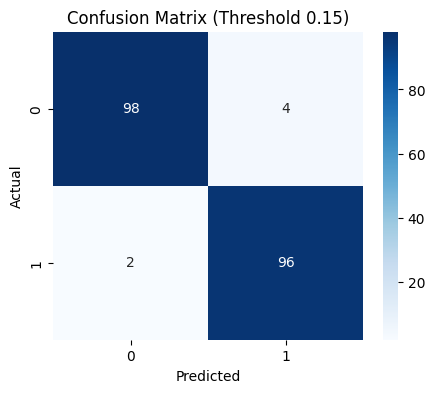

In [74]:
# Confusion Matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_final)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Threshold 0.15)')
plt.show()

## Feature Importance (핵심 변수 분석)

In [75]:
# 중요도 추출
import pandas as pd

feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgb.feature_importances_
})

feature_importance = feature_importance.sort_values(by='importance', ascending=False)

feature_importance.head(10)

,feature,importance
9,frequency,0.311247
10,recency,0.310613
5,avg_days_btwn_sales,0.091538
28,days_to_first_integration,0.048553
7,thrd_quartile_days_btwn_sales,0.024622
3,min_days_btwn_sales,0.024291
2,avg_sales_per_day,0.021159
8,max_days_btwn_sales,0.020584
6,median_days_btwn_sales,0.019584
25,days_to_first_purchase,0.017326


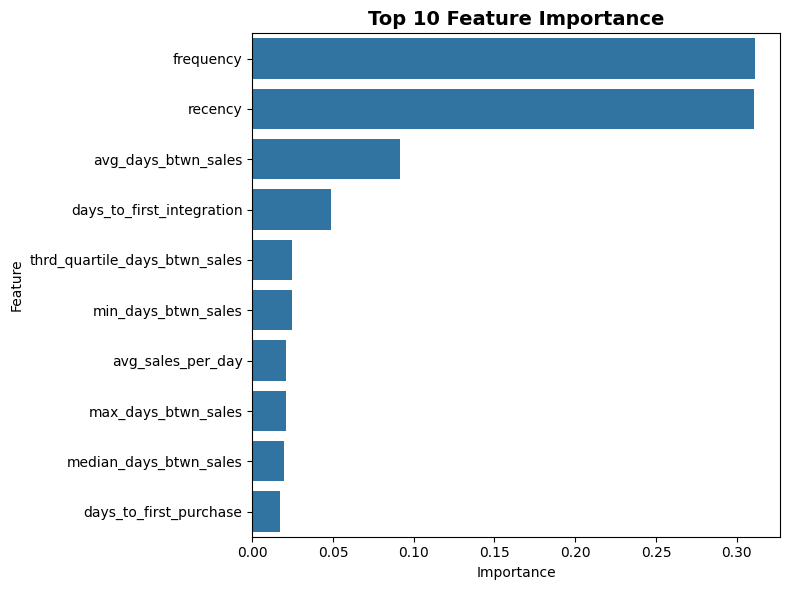

In [76]:
# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

sns.barplot(
    x='importance',
    y='feature',
    data=feature_importance.head(10)
)

plt.title('Top 10 Feature Importance', fontsize=14, fontweight='bold')
plt.xlabel('Importance')
plt.ylabel('Feature')

plt.tight_layout()
plt.show()

# 결론 및 코드 설명
본 모델링 과정에서는 고객 이탈을 예측하기 위해 데이터를 모델이 학습할 수 있는 형태로 변환하고, 다양한 알고리즘을 비교하여 최적의 모델을 선택하는 방식으로 진행하였다. 먼저, 타겟 변수인 Churn을 생성하여 이탈 여부를 이진 분류 문제로 정의하였으며, user_id와 같이 예측에 의미가 없거나 status, churn_factor와 같이 정보 누수 가능성이 있는 변수는 제거하여 모델의 일반화 성능을 확보하였다.

이후 날짜형 변수는 그대로 사용할 수 없기 때문에, 고객의 행동을 반영할 수 있도록 ‘가입 후 첫 구매까지의 기간’, ‘마지막 구매까지의 기간’ 등과 같은 파생변수로 변환하였다. 이는 단순한 시점 정보보다 고객의 활동 패턴을 더 잘 설명할 수 있기 때문이다. 또한 결측치는 일괄적으로 처리하지 않고, 변수의 의미에 따라 다르게 접근하였다. 예를 들어 일부 변수는 단순 누락이 아니라 ‘행동이 발생하지 않음’을 의미하므로 -1과 같은 값으로 처리하여 정보 손실을 최소화하였다.

그 다음 단계에서는 범주형 변수를 모델이 학습할 수 있도록 One-Hot Encoding을 적용하고, 수치형 변수는 이상치에 강건한 RobustScaler를 사용하여 스케일링을 수행하였다. 이는 데이터가 치우친 분포를 가지고 있었기 때문에 모델의 안정적인 학습을 돕기 위한 선택이었다.

모델링 단계에서는 Logistic Regression, Random Forest, XGBoost를 적용하여 성능을 비교하였다. 선형 모델과 트리 기반 모델을 함께 사용한 이유는 데이터의 선형성과 비선형성을 모두 고려하기 위함이며, 그 결과 비선형 관계를 잘 반영하는 XGBoost 모델이 가장 우수한 성능을 보였다. 마지막으로, 기본 threshold(0.5)를 그대로 사용하는 대신 threshold tuning을 통해 예측 기준을 조정하였다. 이는 단순 정확도보다 이탈 고객을 놓치지 않는 것이 더 중요한 문제였기 때문에 Recall을 최대화하는 방향으로 모델을 최적화하기 위함이었다.

결과적으로, 본 모델은 데이터의 특성을 반영한 전처리와 적절한 모델 선택, 그리고 threshold 조정을 통해 이탈 고객을 효과적으로 탐지할 수 있는 모델로 완성되었다.